# Machine Learning: práctica

Vamos a utilizar un dataset de coches `cars.csv`

Queremos predecir la variable `mpg` (miles per gallon)

La métrica para evaluar modelos será RMSE

In [1]:
import pandas as pd
import seaborn as sns

## Carga y exploración

Carga el dataset y explóralo

In [2]:
df = pd.read_csv("./datasets/cars.csv")

In [3]:
df.shape

(388, 9)

<Axes: xlabel='cylinders', ylabel='mpg'>

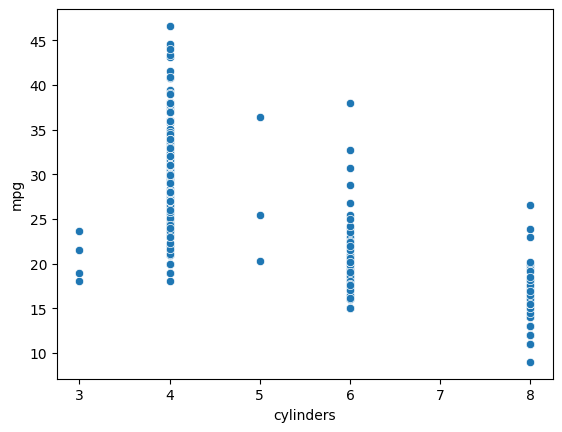

In [7]:
sns.scatterplot(x=df.cylinders, y=df.mpg)

<Axes: xlabel='weight', ylabel='mpg'>

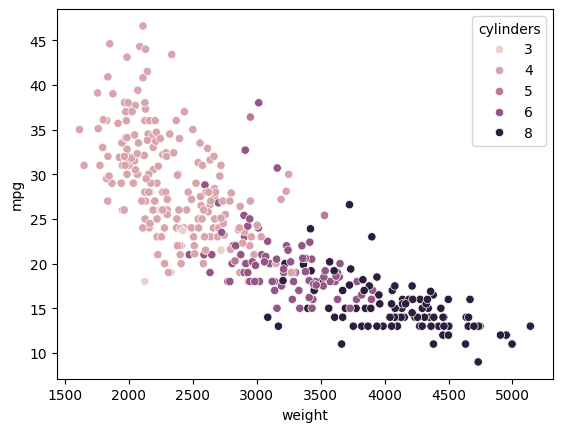

In [10]:
sns.scatterplot(x=df.weight, y=df.mpg, hue=df.cylinders)

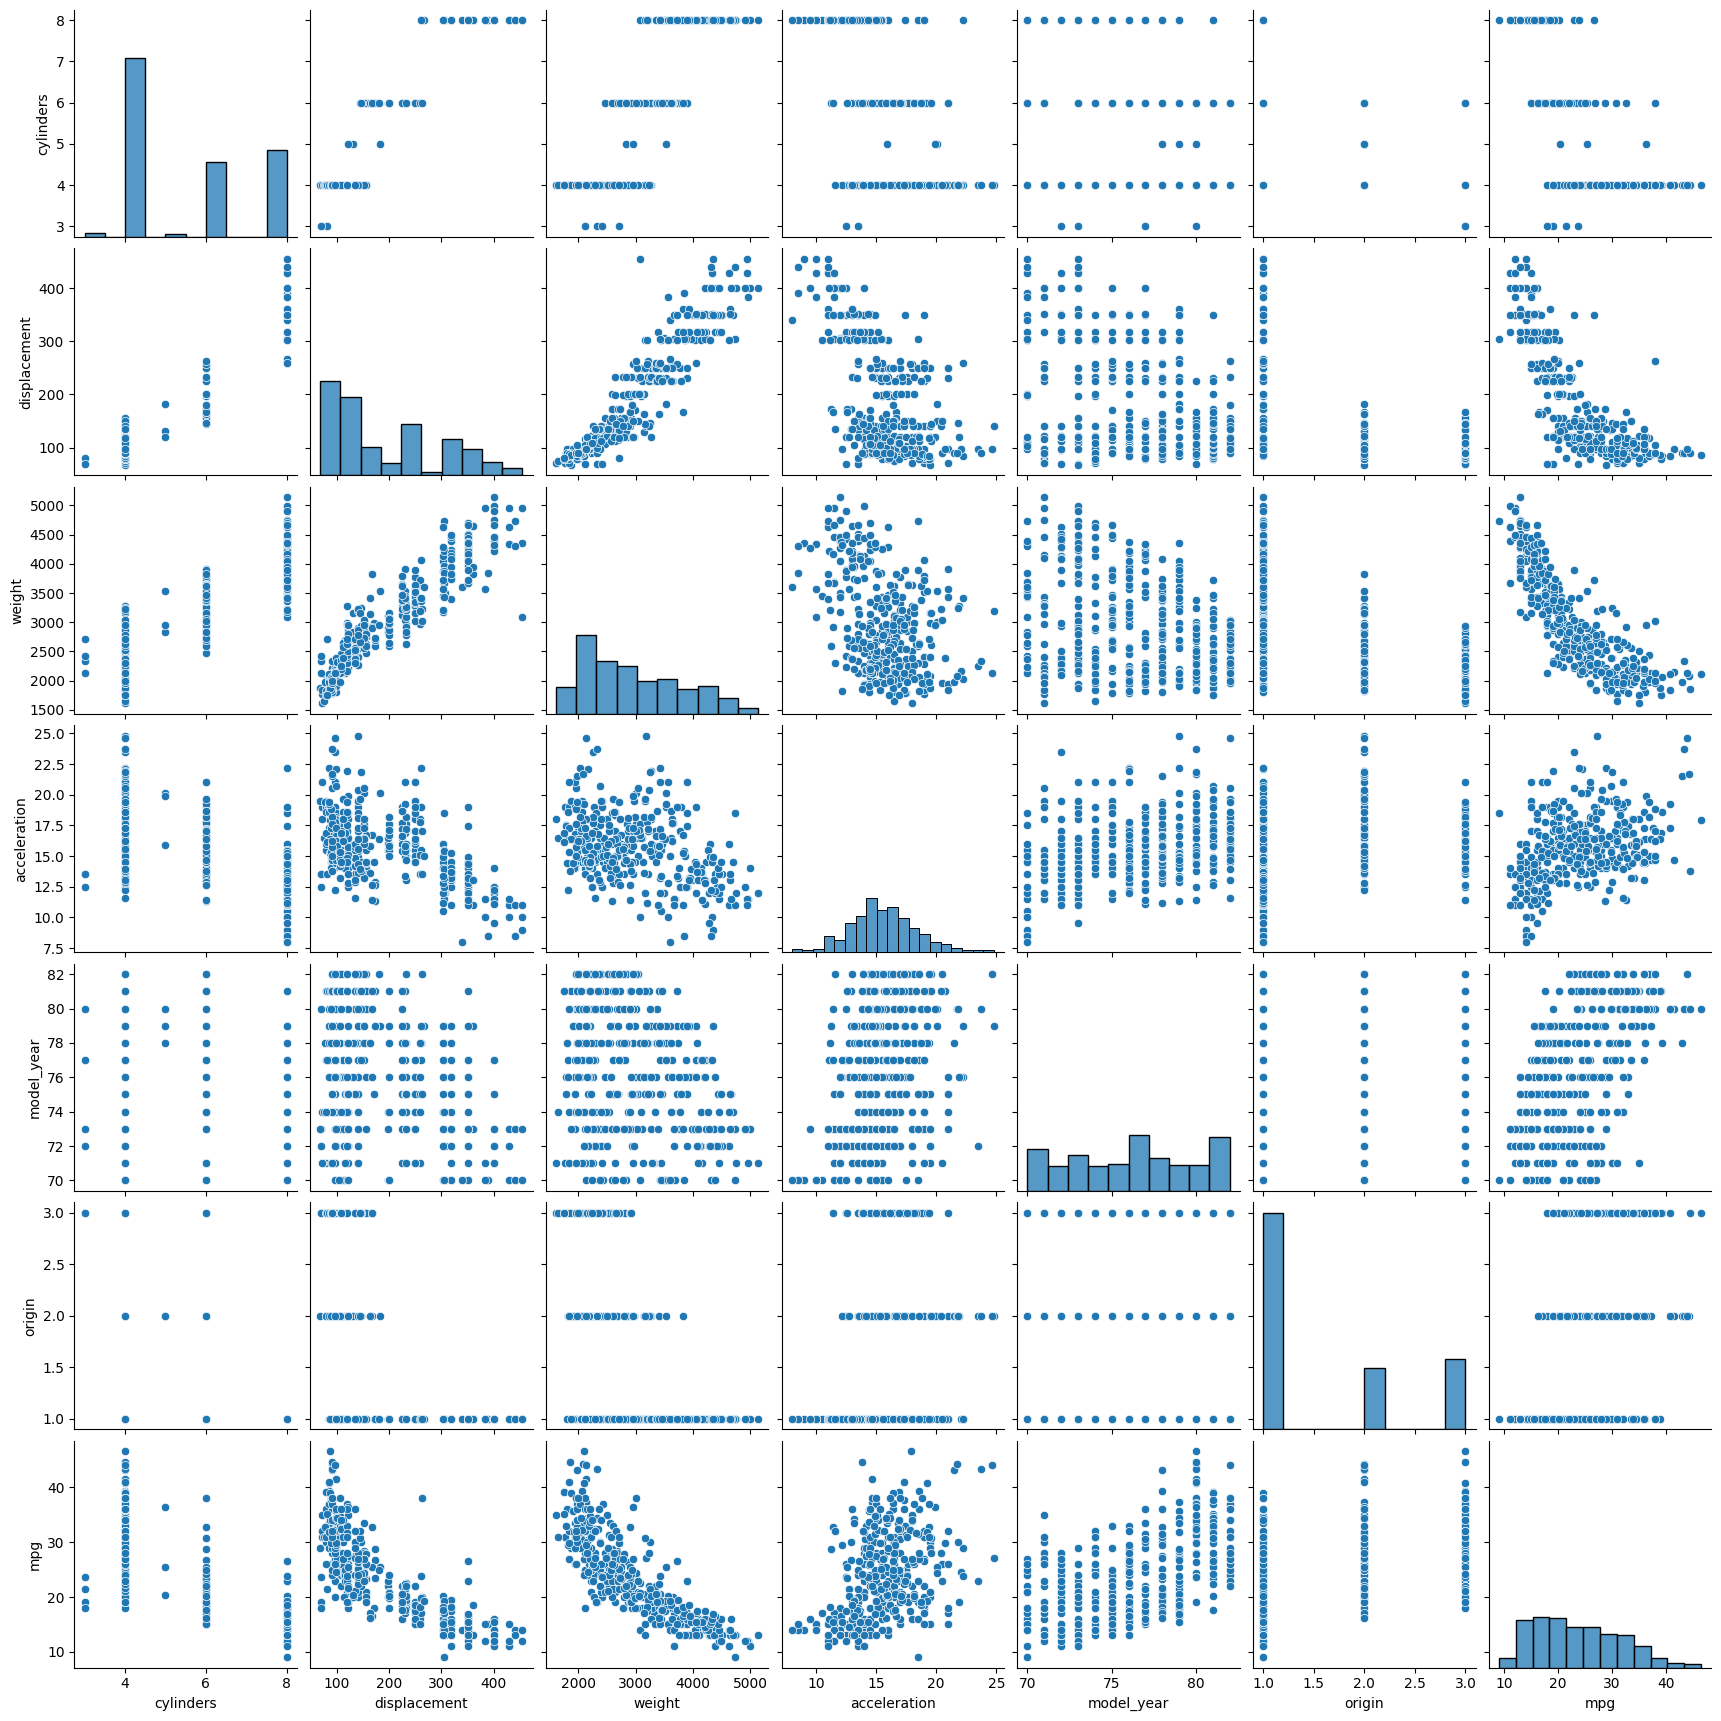

In [12]:
sns.pairplot(df)

In [6]:
df.sort_values("mpg").tail(10)

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name,mpg
237,4,85.0,70,2070,18.6,78.0,3,datsun b210 gx,39.4
314,4,85.0,65,2110,19.2,80.0,3,datsun 210,40.8
320,4,85.0,?,1835,17.3,80.0,2,renault lecar deluxe,40.9
299,4,98.0,76,2144,14.7,80.0,2,vw rabbit,41.5
234,4,90.0,48,1985,21.5,78.0,2,volkswagen rabbit custom diesel,43.1
316,4,90.0,48,2335,23.7,80.0,2,vw dasher (diesel),43.4
384,4,97.0,52,2130,24.6,82.0,2,vw pickup,44.0
315,4,90.0,48,2085,21.7,80.0,2,vw rabbit c (diesel),44.3
319,4,91.0,67,1850,13.8,80.0,3,honda civic 1500 gl,44.6
312,4,86.0,65,2110,17.9,80.0,3,mazda glc,46.6


<Axes: xlabel='mpg', ylabel='Count'>

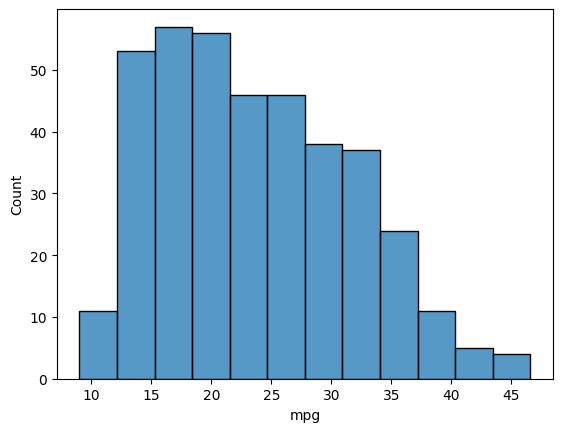

In [4]:
sns.histplot(df.mpg)

Predice mpg

In [7]:
df.head()

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name,mpg
0,8,307.0,130,3504,12.0,70.0,1,chevrolet chevelle malibu,18.0
1,8,350.0,165,3693,11.5,70.0,1,buick skylark 320,15.0
2,8,304.0,150,3433,12.0,70.0,1,amc rebel sst,16.0
3,8,302.0,140,3449,10.5,70.0,1,ford torino,17.0
4,8,429.0,198,4341,10.0,70.0,1,ford galaxie 500,15.0


## Modelado

Utiliza los predictores `displacement` y `acceleration`

In [31]:
df2 = df[["displacement", "acceleration", "mpg"]].copy()

In [32]:
df2.shape

(388, 3)

In [33]:
df2.head()

,displacement,acceleration,mpg
0,307.0,12.0,18.0
1,350.0,11.5,15.0
2,304.0,12.0,16.0
3,302.0,10.5,17.0
4,429.0,10.0,15.0


### Primero, vamos a hacerlo "mal": sin train / test split

- Entrena un modelo con todos los coches
- Predice con el modelo sobre esos mismos coches
- Evalúa el RMSE: realidad vs predicción

In [34]:
from sklearn.linear_model import LinearRegression

In [35]:
df2.head()

,displacement,acceleration,mpg
0,307.0,12.0,18.0
1,350.0,11.5,15.0
2,304.0,12.0,16.0
3,302.0,10.5,17.0
4,429.0,10.0,15.0


In [36]:
lr = LinearRegression()

In [37]:
lr.fit(
    X=df2.drop("mpg", axis=1),
    y=df2.mpg
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [38]:
lr.predict([[300, 11]]).round(1)

/home/sheriff/.devpy/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([17.2])

In [39]:
df2["pred"] = lr.predict(X=df2.drop("mpg", axis=1)).round(1)

In [41]:
df2.head()

,displacement,acceleration,mpg,pred
0,307.0,12.0,18.0,16.7
1,350.0,11.5,15.0,14.1
2,304.0,12.0,16.0,16.9
3,302.0,10.5,17.0,17.1
4,429.0,10.0,15.0,9.3


RMSE

In [44]:
rmse = ((df2.mpg - df2.pred) ** 2).mean().round(1)
rmse

np.float64(21.6)

In [45]:
mse = rmse ** 0.5

In [47]:
mse.round(1)

np.float64(4.6)

### Ahora, vamos a hacerlo bien: con train / test split

- Divide el dataset en train / test (80 / 20)
- Entrena un modelo con los coches de train
- Predice con el modelo sobre los coches de test
- Evalúa el RMSE sobre el test: realidad vs predicción

In [48]:
X = df2.drop("mpg", axis=1)
y = df2.mpg

In [49]:
from sklearn.model_selection import train_test_split

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

In [52]:
X.shape

(388, 3)

In [53]:
X_train.shape

(310, 3)

In [54]:
lr = LinearRegression()

In [55]:
lr.fit(
    X_train,
    y_train
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [59]:
preds_train = lr.predict(X_train).round(1)

In [60]:
preds_train[:5]

array([22.9, 30.1, 28.5, 21.5, 13.4])

In [61]:
y_train.head()

13     18.0
227    30.5
311    32.2
24     19.0
280    15.5
Name: mpg, dtype: float64

In [62]:
rmse_train = ((preds_train - y_train) ** 2).mean().round(1)

In [63]:
rmse_train

np.float64(19.7)

In [65]:
preds_test = lr.predict(X_test).round(1)

In [66]:
preds_test[:5]

array([14.4, 20.2, 13.7, 10.9, 29. ])

In [67]:
y_test.head()

277    16.5
35     18.0
354    26.6
221    15.5
366    37.0
Name: mpg, dtype: float64

In [68]:
((preds_test - y_test) ** 2).mean().round(1)

np.float64(28.0)

### Modelo más complejo

Haz lo mismo con un modelo más complejo (más predictores)